In [1]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
import re

In [2]:
# Carregando os dados
df = pd.read_csv('data/active_alarms_prod.csv')

In [3]:
df['timestamp'] = pd.to_datetime(df['acal_dt_first_occurrence'])

df = df.sort_values(by='timestamp')

# crio uma "sessões" de alarmes
# vou agrupar por node e janela de 10 min
df['session_id'] = (df['timestamp'].diff().dt.seconds > 600).cumsum()

# analisando o que acontece junto em cada session id
grupos = df.groupby('session_id')['acal_tx_alert_type'].apply(list) 

print(grupos.head())

session_id
0                                           [ID-21101]
1    [CAPACITY_MEMORY_USED_PERCENT, HOST_ASSET_MANA...
2    [HOST_ASSET_MANAGER_CERTIFICATE_EXPIRY, HOST_A...
3                              [OPENSHIFT_CLUSTER_PVC]
4                        [SYSTEM_NTP_DATE_NTP_ENABLED]
Name: acal_tx_alert_type, dtype: object


- Nessas sessões, conseguimos separar eventos que ocorreram juntos no mesmo equipamento em um curto intervalo de tempo.
- A sessão 0 mostra um alarme isolado (talvez um ruído)

--- 
## Legibilidade
- O próximo passo é a legibilidade, pois não dá pra saber nada do alarme ID-21101. 
- No arquivo `active_alarms_prod.csv` a coluna `acal_tx_smp_trap` contém o detalhe do aviso.
- Desse modo, queremos limpar os nomes e rodar uma descoberta de padrões.

In [4]:
# 1. Limpando o nome dos alarmes
def extract_real_name(row):
    # Tenta pegar a descrição amigável dentro da Trap SNMP (OID que termina em .0.3.2 geralmente tem o texto)
    # Se não achar, usa o Alert Type padrão
    trap_txt = str(row['acal_tx_snmp_trap'])

    # Regex para encontrar o texto descritico "Value = ..." ou o texto principal
    match = re.search(r'1\.3\.6\.1\.4\.1\.51468\.4\.1\.0\.3\.2=(.*?)(?:,|$)', trap_txt)

    if match:
        # pego o texto e removo os detalhes numéricos específicos para generalizar (remove valores exatos, por exemplo)
        clean_text = match.group(1).split(' (Value')[0] # remove a parte variável (Value = 90 ...)
        return clean_text.strip()
    return row['acal_tx_alert_type']

# 2. Aplicando a limpeza
df['event_signature'] = df.apply(extract_real_name, axis=1)

# 3. Recrio as sessões, mas agora com os nomes limpos
# agrupo pela session id que criamos no inicio
transactions = df.groupby('session_id')['event_signature'].apply(list).tolist()

# Minerando os padrões com o FP - Growth
print(f"Analisando {len(transactions)} sessões de incidentes...")

# formata para o algoritmo
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

# Buscamos itemsets frequentes (grupos de alarmes que aparecem juntos em pelo menos 0.5% das sessões)
# 0.005 = 0.5%
frequent_itemsets = fpgrowth(df_trans, min_support=0.005, use_colnames=True)

# gera as regras de associação (se A -> Então B)

if not frequent_itemsets.empty:
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
    print("Regras de associação encontradas:")
    print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])
else:
    print("Nenhum itemset frequente encontrado com o suporte mínimo especificado.")

Analisando 914 sessões de incidentes...
Regras de associação encontradas:
                                            antecedents  \
0           (SPARK_LIVE_LISTENER_BUS_PROCESSING_EVENTS)   
1     (SPARK_LIVE_LISTENER_BUS_NUMBER_OF_EVENTS, SPA...   
2     (SPARK_LIVE_LISTENER_BUS_PROCESSING_EVENTS, SP...   
3               (SPARK_LIVE_LISTENER_BUS_NUMBER_OF_APP)   
4           (SPARK_LIVE_LISTENER_BUS_PROCESSING_EVENTS)   
...                                                 ...   
2278  (SPARK_LIVE_LISTENER_BUS_NUMBER_OF_APP, SPARK_...   
2279            (SPARK_CODE_GENERATOR_TIME_COMPILATION)   
2280  (DRUID_SERVICE_USAGE, SPARK_LIVE_LISTENER_BUS_...   
2281  (DRUID_SERVICE_USAGE, SPARK_JVM_GARBAGE_COLLEC...   
2282            (3SCALE_PRODUCT_STATUS_CLASS_DEVIATION)   

                                            consequents   support  confidence  \
0            (SPARK_LIVE_LISTENER_BUS_NUMBER_OF_EVENTS)  0.020788    0.703704   
1                   (SPARK_JVM_GARBAGE_COLLECTOR_YOUNG)

---
## Abordagem Híbrida de Clusterização (Tempo + Espaço)

In [5]:
# Vamos fazeruma abordagem híbrida para reduzir o ruído de eventos coincidentes em redes grandes

# 1. Agrupamento hierarquico
# Em vez de diferenciar por 'acal_tx_node', vamos permitir agrupar
# alarmes de diferentes nodes se estiverem no mesmo SITE

df = df.sort_values('timestamp')

# vou definir a "Chave de Topologia" (Podendo ser Site ou região)
df['topology_key'] = df['acal_tx_node_site']  # ou 'acal_tx_region' dependendo do nível desejado

# calcula a diferença de tempo dentro do mesmo site
df['time_diff_site'] = df.groupby('topology_key')['timestamp'].diff().dt.seconds.fillna(0)

# Nova definição da sessão: mesmo site + janela de 10 min
df['site_session_id'] = ((df['time_diff_site'] > 600) | (df['topology_key'] != df['topology_key'].shift())).cumsum()

print(f"Número de sessões baseadas em site: {df['site_session_id'].nunique()}")

Número de sessões baseadas em site: 2367


## Grafo Inicial de Relacionamentos
- Nós: Entidades (Servidores, Pods) e os Tipos de Alarmes
- Arestas: Relações aprendidas pelo FP-Growth(Causalidade Probabilística) e relações físicas (pertencimento)

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

In [7]:
top_rules = rules[rules['lift'] > 1.0].sort_values(by='lift', ascending=False).head(10)

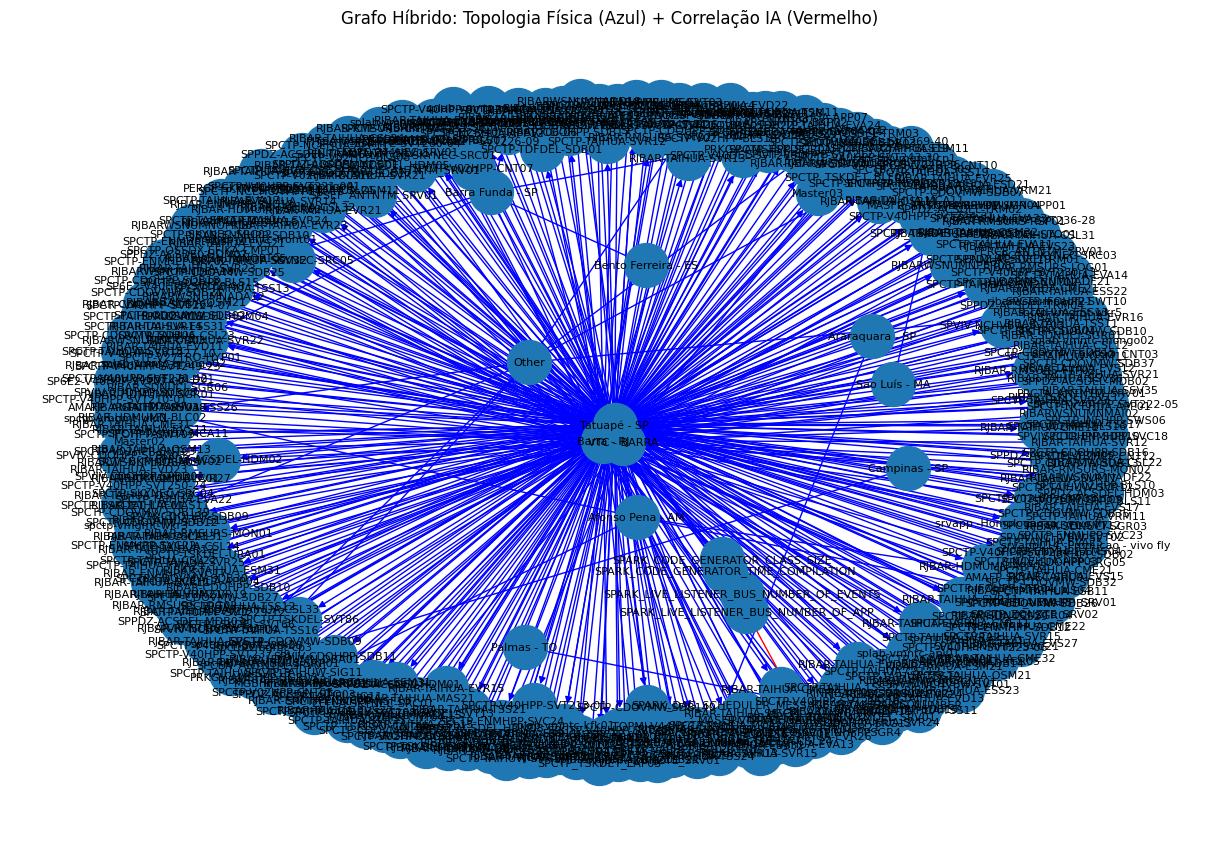

In [8]:
G = nx.DiGraph()

# 1. Adicionar Nós de Infraestrutura (Topologia Estática)
# Ex: Site -> Node
for _, row in df[['acal_tx_node_site', 'acal_tx_node']].drop_duplicates().iterrows():
    if pd.notna(row['acal_tx_node_site']):
        G.add_edge(row['acal_tx_node_site'], row['acal_tx_node'], type='topology', color='blue')

# 2. Adicionar as Regras de Associação (Topologia Dinâmica/Lógica)
# Usamos o output 'rules' do FP-Growth que geramos anteriormente
# Supondo que 'top_rules' seja o seu DataFrame de regras com alto Lift
for _, row in top_rules.head(20).iterrows():
    causa = list(row['antecedents'])[0]
    efeito = list(row['consequents'])[0]
    peso = row['lift']
    
    # Adicionamos a aresta de correlação
    G.add_edge(causa, efeito, weight=peso, type='correlation', color='red')

# 3. Visualização (Diferenciando Físico de Lógico)
pos = nx.spring_layout(G, k=0.5)
colors = [G[u][v]['color'] for u,v in G.edges()]

plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_size=1000, font_size=8, edge_color=colors)
plt.title("Grafo Híbrido: Topologia Física (Azul) + Correlação IA (Vermelho)")
plt.show()

- O que foi chamado de correlação da IA é a relação de causalidade enxergada pelo algoritmo: o alarme A causa o alarme B
- Esse grafo ficou com uma visualização difícil, portanto vou pegar uma amostra

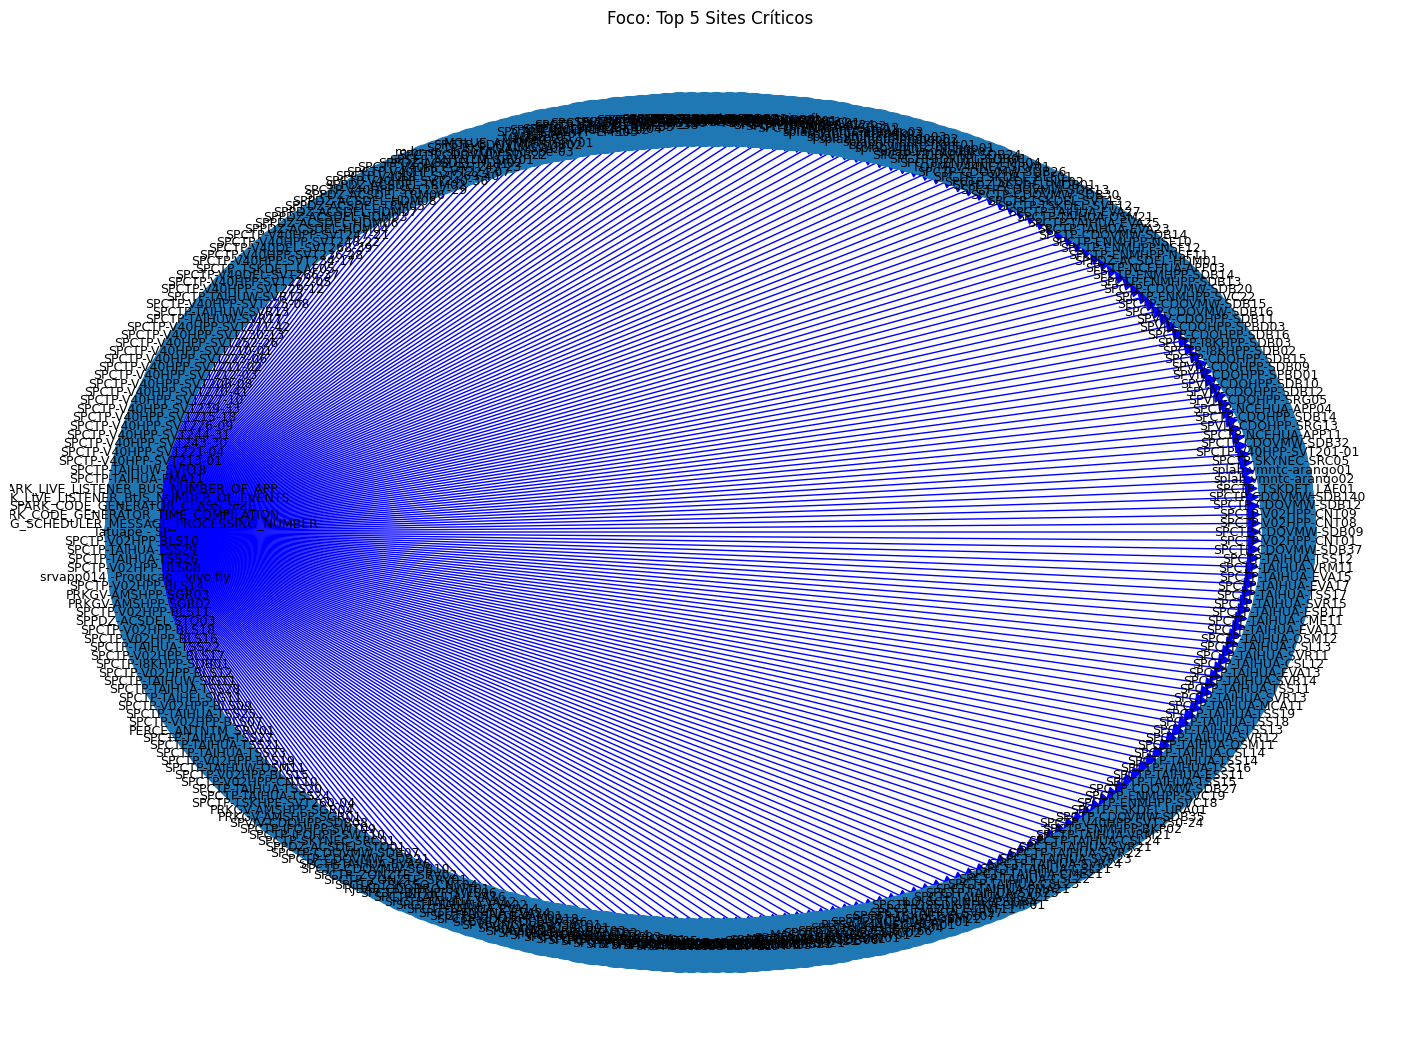

In [9]:
# 1. Selecionar apenas Top 5 Sites com mais problemas
top_sites = df['acal_tx_node_site'].value_counts().head(1).index
df_filtered = df[df['acal_tx_node_site'].isin(top_sites)]

# 2. Recriar o Grafo com escopo reduzido
G_focus = nx.DiGraph()

# Adiciona nós (Topologia)
subset_nodes = df_filtered[['acal_tx_node_site', 'acal_tx_node']].drop_duplicates()
for _, row in subset_nodes.iterrows():
    G_focus.add_node(row['acal_tx_node_site'], type='site', color='green')
    G_focus.add_edge(row['acal_tx_node_site'], row['acal_tx_node'], color='blue', weight=1)

# Adiciona IA (Apenas regras que afetam esses sites)
nodes_in_scope = set(df_filtered['acal_tx_node'].unique())
# (Aqui assumimos que a regra conecta Tipos de Alarme, mas para visualizar no site
# podemos conectar o Node -> Alarme Crítico sugerido pela IA)
for _, row in top_rules.head(10).iterrows(): # Top 10 regras apenas
    # Simplificação visual: Conectar a Causa ao Efeito
    G_focus.add_edge(list(row['antecedents'])[0], list(row['consequents'])[0], color='red', weight=row['lift'])

# 3. Layout Circular (Shell Layout) - Organiza em camadas
# Camada 0: Sites, Camada 1: Nodes, Camada 2: Alarmes
pos = nx.shell_layout(G_focus) 

plt.figure(figsize=(14, 10))
colors = [G_focus[u][v].get('color', 'black') for u,v in G_focus.edges()]
nx.draw(G_focus, pos, with_labels=True, node_size=1500, font_size=9, edge_color=colors, arrowsize=20)
plt.title("Foco: Top 5 Sites Críticos")
plt.show()

In [10]:
import os
from pyvis.network import Network
from IPython.display import display, IFrame

# Define o nome do arquivo
nome_arquivo = "grafo_interativo.html"

# 1. Configuração (Usando 'remote' para garantir que funcione sem arquivos locais extras)
nt = Network(notebook=True, 
             height="600px", 
             width="100%", 
             bgcolor="#222222", 
             font_color="white",
             cdn_resources='remote') # 'remote' é mais seguro se você tem internet

nt.from_nx(G)
nt.show_buttons(filter_=['physics'])

# 2. Salvar explicitamente (Evita conflitos do método .show() dentro de notebooks)
nt.write_html(nome_arquivo)

# 3. Exibir com IFrame (Garante que o HTML renderize na célula)
# Dica: Se ficar em branco, verifique se o arquivo "grafo_interativo.html" foi criado na pasta.
display(IFrame(src=nome_arquivo, width='100%', height='650px'))

In [12]:
# ==============================================================================
# PASSO 4: MOTOR DE CORRELAÇÃO (GERAÇÃO DE EPISÓDIOS)
# Objetivo: Transformar regras abstratas (A->B) em incidentes reais (Site X, Hora Y)
# ==============================================================================

import pandas as pd

# 1. Refinamento de Sessão (Site + Tempo)
# Motivo: Um incidente é local. Não misturamos falhas de sites diferentes.
# ------------------------------------------------------------------------------
df['timestamp'] = pd.to_datetime(df['acal_dt_first_occurrence'])
df = df.sort_values(['acal_tx_node_site', 'timestamp'])

# Define janela de 15 min (900s) para quebra de incidente no mesmo site
df['time_diff'] = df.groupby('acal_tx_node_site')['timestamp'].diff().dt.total_seconds().fillna(0)
# Novo episódio se: Mudou o Site OU Passou muito tempo
df['new_episode'] = (df['time_diff'] > 900) | (df['acal_tx_node_site'] != df['acal_tx_node_site'].shift())
df['episode_id'] = df['new_episode'].cumsum()

print(f"Total de Episódios Gerados: {df['episode_id'].nunique()}")

# 2. Filtragem de Regras de Ouro (Apenas Alta Confiança)
# ------------------------------------------------------------------------------
# Usamos apenas regras com Lift > 1.0 (Correlação Real) para evitar falsos positivos
top_rules_set = rules[rules['lift'] > 1.0].sort_values(by='lift', ascending=False)

# 3. Função "Diagnóstico" (O Coração da IA)
# ------------------------------------------------------------------------------
def diagnosticar_episodio(grupo):
# ATENÇÃO: Usando 'event_signature' que criamos na etapa de limpeza
    alarmes_presentes = set(grupo['event_signature']) 
    
    causa_raiz = "Indeterminado"
    tipo = "Simples Agrupamento"
    max_lift = 0
    match_encontrado = False
    
    for _, row in top_rules_set.iterrows():
        # A regra vem como lista ou string, garantimos que seja string limpa
        ant = list(row['antecedents'])[0] 
        cons = list(row['consequents'])[0]
        
        # DEBUG: Descomente a linha abaixo se quiser ver o que ele está tentando comparar
        # if match_encontrado == False: print(f"Comparando Regra: {ant} com Alarmes: {list(alarmes_presentes)[:1]}")

        if ant in alarmes_presentes and cons in alarmes_presentes:
            if row['lift'] > max_lift:
                max_lift = row['lift']
                causa_raiz = ant
                tipo = f"IA Confirmada (Lift {row['lift']:.1f})"
                match_encontrado = True
    
    return pd.Series({
        'Inicio': grupo['timestamp'].min(),
        'Site': grupo['acal_tx_node_site'].iloc[0],
        'Qtd_Alarmes': len(grupo), # Isso é sua métrica de sucesso principal!
        'Causa_Raiz': causa_raiz,
        'Tipo_Diagnostico': tipo,
        'Exemplo_Alarme_Limpo': list(alarmes_presentes)[0] # Para checarmos se o nome está limpo mesmo
    })

# Rodar novamente com a função corrigida
print("Rodando diagnóstico corrigido...")
df_resultado_final = df.groupby('episode_id').apply(diagnosticar_episodio).sort_values('Qtd_Alarmes', ascending=False)

display(df_resultado_final.head(10))

Total de Episódios Gerados: 2287
Rodando diagnóstico corrigido...


C:\Users\lucga\AppData\Local\Temp\ipykernel_12484\645108149.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_resultado_final = df.groupby('episode_id').apply(diagnosticar_episodio).sort_values('Qtd_Alarmes', ascending=False)


,Inicio,Site,Qtd_Alarmes,Causa_Raiz,Tipo_Diagnostico,Exemplo_Alarme_Limpo
episode_id,,,,,,
457,2025-12-05 08:04:08.133437,Tatuapé - SP,1509,Indeterminado,Simples Agrupamento,STORAGE_VOLUME_STATUS_IO_PER_SECOND_MAX
375,2025-11-11 00:05:04.217494,Tatuapé - SP,317,Indeterminado,Simples Agrupamento,STORAGE_PHYSICAL_DISK_ALLOCATION_STATUS_USED_P...
483,2025-11-30 14:45:36.368337,VTC - BARRA,175,Indeterminado,Simples Agrupamento,SOFTWARE_SERVICE_STATUS_INFO
131,2025-08-22 18:35:05.172093,Tatuapé - SP,152,Indeterminado,Simples Agrupamento,SYSTEM_NTP_DATE_NTP_SYNCHRONIZED
229,2025-10-10 12:00:07.892266,Tatuapé - SP,105,Indeterminado,Simples Agrupamento,SOFTWARE_SERVICE_STATUS_INFO
349,2025-11-03 04:56:31.657536,Tatuapé - SP,101,Indeterminado,Simples Agrupamento,SOFTWARE_SERVICE_STATUS_INFO
371,2025-11-08 21:15:10.079163,Tatuapé - SP,98,Indeterminado,Simples Agrupamento,CONNECTIVITY_PORT_STATE_INFO
315,2025-10-26 20:05:14.734148,Tatuapé - SP,97,Indeterminado,Simples Agrupamento,CONNECTIVITY_PORT_STATE_INFO
8,2025-08-22 18:27:09.081405,Barra - RJ,86,Indeterminado,Simples Agrupamento,HOST_ASSET_MANAGER_CERTIFICATE_EXPIRY


In [13]:
# Vamos filtrar explicitamente onde a IA encontrou algo
df_ia_confirmada = df_resultado_final[df_resultado_final['Causa_Raiz'] != 'Indeterminado']

print(f"Total de Episódios com Diagnóstico de IA: {len(df_ia_confirmada)}")

if len(df_ia_confirmada) > 0:
    print("Exibindo casos onde a IA identificou a Causa Raiz:")
    display(df_ia_confirmada.head())
else:
    print("Nenhum match exato encontrado. Vamos investigar as Regras vs. Alarmes.")
    # Debug: Mostrar as top regras que a IA aprendeu para você comparar visualmente
    print("\n--- O que a IA aprendeu (Regras) ---")
    print(top_rules_set[['antecedents', 'consequents', 'lift']].head())
    
    print("\n--- O que temos nos episódios (Alarmes Reais) ---")
    print(df_resultado_final['Exemplo_Alarme_Limpo'].unique()[:10])

Total de Episódios com Diagnóstico de IA: 45
Exibindo casos onde a IA identificou a Causa Raiz:


,Inicio,Site,Qtd_Alarmes,Causa_Raiz,Tipo_Diagnostico,Exemplo_Alarme_Limpo
episode_id,,,,,,
164,2025-09-08 13:57:48.078632,Tatuapé - SP,13,CAPACITY_DISK_INODES_IUSED_PERCENT,IA Confirmada (Lift 14.5),CAPACITY_DISK_INODES_IUSED_PERCENT
150,2025-09-01 15:30:31.151309,Tatuapé - SP,11,CAPACITY_DISK_INODES_IUSED_PERCENT,IA Confirmada (Lift 14.5),CAPACITY_DISK_INODES_IUSED_PERCENT
130,2025-12-02 12:46:53.347011,São Luís - MA,6,CAPACITY_DISK_INODES_IUSED_PERCENT,IA Confirmada (Lift 14.5),CAPACITY_DISK_INODES_IUSED_PERCENT
280,2025-10-22 14:37:27.222242,Tatuapé - SP,6,CAPACITY_DISK_INODES_IUSED_PERCENT,IA Confirmada (Lift 14.5),CAPACITY_DISK_INODES_IUSED_PERCENT
393,2025-11-18 12:00:09.129102,Tatuapé - SP,5,CAPACITY_DISK_INODES_IUSED_PERCENT,IA Confirmada (Lift 14.5),CAPACITY_DISK_INODES_IUSED_PERCENT


- Aqui observa-se que quando os Inodes do disco enchem, uma série de outros erros acontece em sequência (poderiam ser falhas de escrita, travamento do banco ou erro de ciração de arquivos temporários (?))
- A sugestão, caso ainda não exista, seria criar uma automação que limpa os arquivos temporários sempre que o alarme em específico disparar.